# SO2

In [29]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from pathlib import Path

PETRONOR = (43.328065, -3.109722)

STATION_COORDS = {
    "ALGORTA_BBIZI2":    (43.362056, -3.022782),
    "BARAKALDO":  (43.296,    -2.989),
    "BASAURI":    (43.239,    -2.885),
    "ERANDIO":    (43.307,    -2.973),
    "MAZARREDO":  (43.263,    -2.935),
    "MUSKIZ":     (43.323,    -3.113),
    "SANTURTZI":  (43.323,    -3.032),
}

In [30]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

rows = []
for station, (lat, lon) in STATION_COORDS.items():
    dist = haversine_km(lat, lon, PETRONOR[0], PETRONOR[1])
    rows.append({"station": station, "dist_petronor_km": round(dist, 2)})

dist_df = pd.DataFrame(rows).sort_values("dist_petronor_km")
print(dist_df.to_string(index=False))

       station  dist_petronor_km
        MUSKIZ              0.62
     SANTURTZI              6.31
ALGORTA_BBIZI2              7.98
     BARAKALDO             10.40
       ERANDIO             11.31
     MAZARREDO             15.88
       BASAURI             20.71


In [31]:
df = pd.read_parquet("../data/processed/air_quality_weather.parquet")

so2_means = (
    df.groupby("station")["SO2"]
    .mean()
    .reset_index()
    .rename(columns={"SO2": "mean_SO2"})
)

so2_means

,station,mean_SO2
0,ALGORTA_BBIZI2,4.623789
1,BARAKALDO,5.595327
2,BASAURI,3.430109
3,ERANDIO,4.308846
4,MAZARREDO,6.178957
5,MUSKIZ,4.681434
6,SANTURCE,4.746528


In [34]:
#  Normalize
so2_means["station_short"] = (
    so2_means["station"].str.split("_").str[0].str.upper()
)

dist_df["station_short"] = (
    dist_df["station"].str.split("_").str[0].str.upper()
    .replace({"SANTURTZI": "SANTURCE"})
)

merged = dist_df.merge(
    so2_means[["station_short", "mean_SO2"]],
    on="station_short",
    how="left"
)

final_df = merged[["dist_petronor_km", "station_short", "mean_SO2"]]
final_df


,dist_petronor_km,station_short,mean_SO2
0,0.62,MUSKIZ,4.681434
1,6.31,SANTURCE,4.746528
2,7.98,ALGORTA,4.623789
3,10.40,BARAKALDO,5.595327
4,11.31,ERANDIO,4.308846
5,15.88,MAZARREDO,6.178957
6,20.71,BASAURI,3.430109


In [35]:
print(merged[["station", "dist_petronor_km", "mean_SO2"]].to_string(index=False))

       station  dist_petronor_km  mean_SO2
        MUSKIZ              0.62  4.681434
     SANTURTZI              6.31  4.746528
ALGORTA_BBIZI2              7.98  4.623789
     BARAKALDO             10.40  5.595327
       ERANDIO             11.31  4.308846
     MAZARREDO             15.88  6.178957
       BASAURI             20.71  3.430109


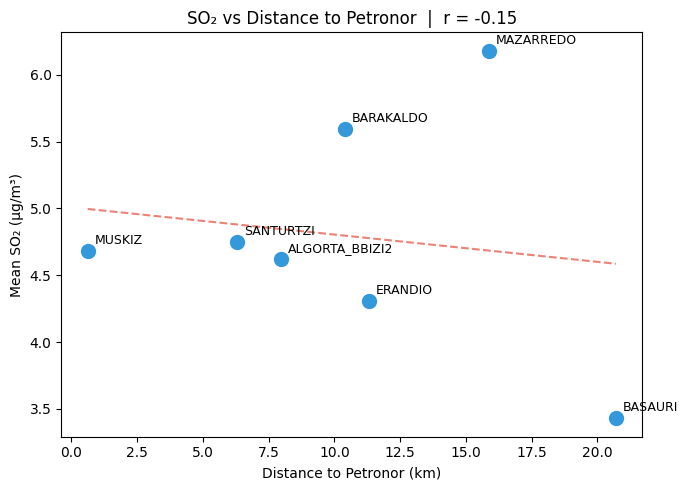

Pearson r = -0.150


In [36]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged["dist_petronor_km"], merged["mean_SO2"], s=100, color="#3498db")

for _, row in merged.iterrows():
    ax.annotate(row["station"], (row["dist_petronor_km"], row["mean_SO2"]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

# Trend line
m, b = np.polyfit(merged["dist_petronor_km"].dropna(),
                  merged["mean_SO2"].dropna(), 1)
x_line = np.linspace(merged["dist_petronor_km"].min(),
                     merged["dist_petronor_km"].max(), 100)
ax.plot(x_line, m * x_line + b, "--", color="#e74c3c", alpha=0.7)

corr = merged["dist_petronor_km"].corr(merged["mean_SO2"])
ax.set_xlabel("Distance to Petronor (km)")
ax.set_ylabel("Mean SO₂ (µg/m³)")
ax.set_title(f"SO₂ vs Distance to Petronor  |  r = {corr:.2f}")
plt.tight_layout()
plt.savefig("../reports/so2_vs_petronor_distance.png", dpi=150)
plt.show()
print(f"Pearson r = {corr:.3f}")

r = -0.15 — There is virtually no spatial relationship between distance to Petronor and SO2.

This result is important and should be interpreted honestly:

Why we expected r to be strong but it is not:

MAZARREDO (urban, far from Petronor) has the highest SO2 — meaning that SO2 in Bilbao comes from traffic and diesel, not just the refinery

BASAURI (industrial, very far) has the lowest SO2

MUSKIZ (closest to Petronor) is in the middle — neither high nor low

Physical interpretation: SO2 in this area does not have a dominant point source. Emissions are diffuse and wind, valley topography, and local source composition play a greater role than linear distance to Petronor.

# NO2